In [ ]:
!pip install timm torchmetrics -q

In [2]:
!nvidia-smi

Sun Mar 22 02:32:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
#All imports

import os, sys, math, json, random, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import timm

warnings.filterwarnings('ignore')

# ── Reproducibility seed ────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True   # set True after debugging if speed needed

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
#Configurations (paths, hyperparams, class names, etc.)

IMAGE_ROOT  = '/kaggle/input/datasets/horizon8161/gsoc-painting/wikiart_kaggle_data'
MASTER_CSV  = '/kaggle/input/datasets/horizon8161/gsoc-painting/wikiart_kaggle_data/dataset.csv'
CKPT_DIR    = '/kaggle/working/checkpoints'
LOG_DIR     = '/kaggle/working/logs'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,  exist_ok=True)

# ── Class definitions (from .txt files, fixed order) ───────────────
ARTIST_CLASSES = [
    'Albrecht_Durer','Boris_Kustodiev','Camille_Pissarro','Childe_Hassam',
    'Claude_Monet','Edgar_Degas','Eugene_Boudin','Gustave_Dore','Ilya_Repin',
    'Ivan_Aivazovsky','Ivan_Shishkin','John_Singer_Sargent','Marc_Chagall',
    'Martiros_Saryan','Nicholas_Roerich','Pablo_Picasso','Paul_Cezanne',
    'Pierre_Auguste_Renoir','Pyotr_Konchalovsky','Raphael_Kirchner',
    'Rembrandt','Salvador_Dali','Vincent_van_Gogh',
]
GENRE_CLASSES = [
    'abstract_painting','cityscape','genre_painting','illustration',
    'landscape','nude_painting','portrait','religious_painting',
    'sketch_and_study','still_life',
]
STYLE_CLASSES = [
    'Abstract_Expressionism','Action_painting','Analytical_Cubism','Art_Nouveau',
    'Baroque','Color_Field_Painting','Contemporary_Realism','Cubism',
    'Early_Renaissance','Expressionism','Fauvism','High_Renaissance',
    'Impressionism','Mannerism_Late_Renaissance','Minimalism',
    'Naive_Art_Primitivism','New_Realism','Northern_Renaissance','Pointillism',
    'Pop_Art','Post_Impressionism','Realism','Rococo','Romanticism',
    'Symbolism','Synthetic_Cubism','Ukiyo_e',
]

# String → integer index maps (used in Dataset.__getitem__)
ARTIST2IDX = {name: i for i, name in enumerate(ARTIST_CLASSES)}
GENRE2IDX  = {name: i for i, name in enumerate(GENRE_CLASSES)}
STYLE2IDX  = {name: i for i, name in enumerate(STYLE_CLASSES)}

N_ARTIST = len(ARTIST_CLASSES)   # 23
N_GENRE  = len(GENRE_CLASSES)    # 10
N_STYLE  = len(STYLE_CLASSES)    # 27

# ── Image / training hyperparams ───────────────────────────────────
IMG_SIZE      = 256     # final crop size fed to model
RESIZE_TO     = 288     # resize shorter side before cropping
BATCH_SIZE    = 32      # reduce to 8 if OOM
NUM_EPOCHS    = 15      # Stage C full run; use 5 for Stage A/B
LR_BACKBONE   = 1e-5   # pretrained ConvNeXt + HRNet weights
LR_NEW        = 1e-4   # fusion + BiLSTM + heads
WEIGHT_DECAY  = 1e-2
WARMUP_EPOCHS = 3
GRAD_CLIP     = 1.0

# ── Multi-task loss weights ─────────────────────────────────────────
LAMBDA_ARTIST = 1.2    # hardest task — finest-grained
LAMBDA_GENRE  = 1.0
LAMBDA_STYLE  = 0.8    # most data, converges fastest

print("Config loaded.")
print(f"Classes — Artist: {N_ARTIST} | Genre: {N_GENRE} | Style: {N_STYLE}")

Config loaded.
Classes — Artist: 23 | Genre: 10 | Style: 27


In [ ]:
#Data loading and class weight computation

df = pd.read_csv(MASTER_CSV)

# ── Sanity check ────────────────────────────────────────────────────
print(f"master_df shape : {df.shape}")
print(f"Columns         : {df.columns.tolist()}")
print(f"Split counts    : {df.split.value_counts().to_dict()}")
print(f"n_labels counts : {df.n_labels.value_counts().sort_index().to_dict()}")
print()

# ── Train / Val split ───────────────────────────────────────────────
train_df = df[df.split == 'train'].reset_index(drop=True)
val_df   = df[df.split == 'val'].reset_index(drop=True)
print(f"Train rows: {len(train_df):,}  |  Val rows: {len(val_df):,}")

# ── Compute class weights (inverse frequency, per task) ────────────
# Formula: w_c = total_labelled / (n_classes * count_c)
# Images without a label for a task are excluded from that count.
# Result: a 1-D tensor of length n_classes fed to CrossEntropyLoss.

def compute_class_weights(df, name_col, class_list, device):
    """
    df        : DataFrame (train split only)
    name_col  : column name, e.g. 'artist_name'
    class_list: ordered list, index = class id
    Returns   : FloatTensor of shape [n_classes] on device
    """
    counts    = Counter(df[df[name_col] != 'unknown'][name_col].tolist())
    n_classes = len(class_list)
    total     = sum(counts.values())
    weights   = []
    for cls in class_list:
        cnt = counts.get(cls, 1)          # 1 avoids div-by-zero for unseen class
        weights.append(total / (n_classes * cnt))
    w = torch.tensor(weights, dtype=torch.float32).to(device)
    return w

w_artist = compute_class_weights(train_df, 'artist_name', ARTIST_CLASSES, DEVICE)
w_genre  = compute_class_weights(train_df, 'genre_name',  GENRE_CLASSES,  DEVICE)
w_style  = compute_class_weights(train_df, 'style_name',  STYLE_CLASSES,  DEVICE)

print("\nClass weight sanity check:")
print(f"  Artist — min: {w_artist.min().item():.3f}  max: {w_artist.max().item():.3f}")
print(f"  Genre  — min: {w_genre.min().item():.3f}  max: {w_genre.max().item():.3f}")
print(f"  Style  — min: {w_style.min().item():.3f}  max: {w_style.max().item():.3f}")

# Style should show the biggest spread (136x imbalance)
# Action_painting weight should be ~12-15x Impressionism's weight
imp_w   = w_style[STYLE_CLASSES.index('Impressionism')].item()
act_w   = w_style[STYLE_CLASSES.index('Action_painting')].item()
print(f"\n  Style weight ratio (Action_painting / Impressionism) = {act_w/imp_w:.1f}x  ")

master_df shape : (80097, 10)
Columns         : ['fname', 'rel_path', 'artist_name', 'genre_name', 'style_name', 'split', 'has_artist', 'has_genre', 'has_style', 'n_labels']
Split counts    : {'train': 56137, 'val': 23960}
n_labels counts : {1: 12301, 2: 51546, 3: 16250}

Train rows: 56,137  |  Val rows: 23,960

Class weight sanity check:
  Artist — min: 0.439  max: 1.727
  Genre  — min: 0.461  max: 3.428
  Style  — min: 0.231  max: 31.502

  Style weight ratio (Action_painting / Impressionism) = 136.7x  


In [ ]:
#Data augmentation, Dataset, WeightedRandomSampler, DataLoaders

# Transforms 
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    # Resize shorter side → gives padding around the 384 crop
    T.Resize(RESIZE_TO, interpolation=T.InterpolationMode.BICUBIC),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    # Mild jitter only — aggressive color changes destroy style signals
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = T.Compose([
    T.Resize(RESIZE_TO, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


# Dataset
class ArtDataset(Dataset):
    """
    Reads images from IMAGE_ROOT / row['rel_path'].
    Returns image tensor + three integer labels.
    Label = -1 when not available for that task (handled by ignore_index).
    """
    def __init__(self, df, image_root, transform=None):
        self.df         = df.reset_index(drop=True)
        self.image_root = Path(image_root)
        self.transform  = transform

        # Pre-build a grey fallback image (used if file is missing on disk)
        self._fallback  = Image.fromarray(
            (np.ones((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8) * 128)
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = self.image_root / row['rel_path']

        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            img = self._fallback

        if self.transform:
            img = self.transform(img)

        # Convert name → integer index; 'unknown' → -1
        artist_id = ARTIST2IDX.get(row['artist_name'], -1)
        genre_id  = GENRE2IDX.get(row['genre_name'],   -1)
        style_id  = STYLE2IDX.get(row['style_name'],   -1)

        return {
            'image':     img,
            'artist_id': torch.tensor(artist_id, dtype=torch.long),
            'genre_id':  torch.tensor(genre_id,  dtype=torch.long),
            'style_id':  torch.tensor(style_id,  dtype=torch.long),
            'fname':     row['fname'],
        }


# WeightedRandomSampler (driven by style — most imbalanced task) ─
def make_sampler(df):
    """
    Each image's sampling probability ∝ 1 / count_of_its_style_class.
    Images with no style label get a small but non-zero weight.
    """
    style_counts = Counter(
        df[df.style_name != 'unknown'].style_name.tolist()
    )
    min_count    = min(style_counts.values())   # rarest class count

    sample_weights = []
    for _, row in df.iterrows():
        if row['style_name'] != 'unknown':
            w = 1.0 / style_counts[row['style_name']]
        else:
            # Images without style label → use min count so they appear occasionally
            w = 1.0 / min_count
        sample_weights.append(w)

    return WeightedRandomSampler(
        weights     = sample_weights,
        num_samples = len(sample_weights),
        replacement = True,
    )


# ── DataLoaders ─────────────────────────────────────────────────────
train_dataset = ArtDataset(train_df, IMAGE_ROOT, train_transform)
val_dataset   = ArtDataset(val_df,   IMAGE_ROOT, val_transform)

sampler = make_sampler(train_df)

train_loader = DataLoader(
    train_dataset,
    batch_size        = BATCH_SIZE,
    sampler           = sampler,  # replaces shuffle=True
    num_workers       = 4,
    pin_memory        = True,
    persistent_workers= True,     
    prefetch_factor   = 2,        
    drop_last         = True,     # avoids batch-norm issues on final tiny batch
)

val_loader = DataLoader(
    val_dataset,
    batch_size        = BATCH_SIZE * 2,  # can use larger batch on val (no gradients)
    shuffle           = False,
    num_workers       = 4,
    pin_memory        = True,
    persistent_workers= True,     
    prefetch_factor   = 2,        
)

print(f"Train dataset : {len(train_dataset):,} images  →  {len(train_loader)} batches")
print(f"Val   dataset : {len(val_dataset):,} images  →  {len(val_loader)} batches")

# ── Quick image shape sanity check ──────────────────────────────────
sample_batch = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  image shape : {sample_batch['image'].shape}")   # (B, 3, 256, 256)
print(f"  artist_ids  : {sample_batch['artist_id'][:8].tolist()}")
print(f"  genre_ids   : {sample_batch['genre_id'][:8].tolist()}")
print(f"  style_ids   : {sample_batch['style_id'][:8].tolist()}")
print("  (−1 = no label for this task — handled by ignore_index)")

Train dataset : 56,137 images  →  1754 batches
Val   dataset : 23,960 images  →  375 batches

Sample batch:
  image shape : torch.Size([32, 3, 256, 256])
  artist_ids  : [-1, -1, -1, -1, -1, -1, -1, -1]
  genre_ids   : [7, 0, 4, 0, 9, 7, -1, 6]
  style_ids   : [13, 1, 18, 5, 2, 11, 14, 0]
  (−1 = no label for this task — handled by ignore_index)


In [ ]:
#Architectures

class StageA_ConvNeXt(nn.Module):
    """
    ConvNeXt-Base with three classification heads.
    No HRNet, no LSTM — pure CNN baseline.
    ~88M backbone params.
    """
    def __init__(self, n_artist=N_ARTIST, n_genre=N_GENRE, n_style=N_STYLE,
                 dropout=0.3):
        super().__init__()
        # num_classes=0 → returns pooled embedding, not logits
        self.backbone = timm.create_model(
            'convnext_small', pretrained=True, num_classes=0
        )
        d = self.backbone.num_features   # 1024

        self.dropout      = nn.Dropout(dropout)
        self.head_artist  = nn.Linear(d, n_artist)
        self.head_genre   = nn.Linear(d, n_genre)
        self.head_style   = nn.Linear(d, n_style)

    def forward(self, x):
        emb = self.backbone(x)      # (B, 1024)
        emb = self.dropout(emb)
        return {
            'artist':    self.head_artist(emb),
            'genre':     self.head_genre(emb),
            'style':     self.head_style(emb),
            'embedding': emb,
        }


#Full model with ConvNeXt + HRNet + BiLSTM
class ArtExtractModel(nn.Module):
    """
    Hybrid CNN + Bi-LSTM multi-task painting classifier.
    
    """
    def __init__(self, n_artist=N_ARTIST, n_genre=N_GENRE, n_style=N_STYLE,
                 d_model=512, lstm_hidden=256, lstm_layers=1, dropout=0.3):
        super().__init__()

        # ── Backbone 1: ConvNeXt-Base ─────────────────────────────
        # features_only=True returns intermediate feature maps
        self.convnext = timm.create_model(
            'convnext_small',
            pretrained=True,
            features_only=True,
            out_indices=[3],        # last stage only → 12×12×1024
        )
        c1 = self.convnext.feature_info[-1]['num_chs']   # 1024

        # ── Backbone 2: HRNet-W18 ────────────────────────────────────────
        self.hrnet = timm.create_model(
            'hrnet_w18',
            pretrained=True,
            num_classes=0,
            global_pool='',
        )
        
        # Probe actual output channels — don't hardcode
        with torch.no_grad():
            _dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            _feat  = self.hrnet.forward_features(_dummy)
            c2     = _feat.shape[1]   # will be 2048 for hrnet_w18
        print(f"HRNet output channels: {c2}")

        # ── Channel projection + fusion ───────────────────────────
        # Both projected to d_model/2 then concatenated → d_model
        self.proj_convnext = nn.Sequential(
            nn.Conv2d(c1, d_model // 2, kernel_size=1, bias=False),
            nn.BatchNorm2d(d_model // 2),
            nn.ReLU(inplace=True),
        )
        self.proj_hrnet = nn.Sequential(
            nn.Conv2d(c2, d_model // 2, kernel_size=1, bias=False),
            nn.BatchNorm2d(d_model // 2),
            nn.ReLU(inplace=True),
        )
        self.fuse_bn = nn.BatchNorm2d(d_model)

        # ── Bidirectional LSTM ────────────────────────────────────
        # Input  : (batch, seq_len=144, d_model=512)
        # Output : (batch, seq_len=144, lstm_hidden*2=512)
        self.bilstm = nn.LSTM(
            input_size    = d_model,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if lstm_layers > 1 else 0.0,
        )
        lstm_out_dim = lstm_hidden * 2   # 512 (bidirectional doubles it)

        # ── Dropout + Classification heads ────────────────────────
        self.dropout     = nn.Dropout(dropout)
        self.head_artist = nn.Linear(lstm_out_dim, n_artist)
        self.head_genre  = nn.Linear(lstm_out_dim, n_genre)
        self.head_style  = nn.Linear(lstm_out_dim, n_style)

    def forward(self, x):
        # ── ConvNeXt features ─────────────────────────────────────
        feat_c = self.convnext(x)[0]          # (B, 1024, 12, 12)

        # ── HRNet features ────────────────────────────────────────
        feat_h = self.hrnet.forward_features(x)   # (B, 270, 48, 48)

        # Align spatial size to ConvNeXt output (12×12)
        H, W  = feat_c.shape[-2], feat_c.shape[-1]
        feat_h = F.interpolate(
            feat_h, size=(H, W), mode='bilinear', align_corners=False
        )                                     # (B, 270, 12, 12)

        # ── Project + concat + normalize ─────────────────────────
        p_c   = self.proj_convnext(feat_c)    # (B, 256, 12, 12)
        p_h   = self.proj_hrnet(feat_h)       # (B, 256, 12, 12)
        fused = torch.cat([p_c, p_h], dim=1)  # (B, 512, 12, 12)
        fused = self.fuse_bn(fused)

        # ── Flatten spatial → sequence ────────────────────────────
        # (B, C, H, W) → (B, H*W, C)
        B, C, H, W = fused.shape
        seq = fused.flatten(2).permute(0, 2, 1)   # (B, 144, 512)

        # ── BiLSTM ───────────────────────────────────────────────
        lstm_out, _ = self.bilstm(seq)         # (B, 144, 512)
        emb = lstm_out.mean(dim=1)             # mean-pool → (B, 512)
        emb = self.dropout(emb)

        # ── Heads ────────────────────────────────────────────────
        return {
            'artist':    self.head_artist(emb),   # (B, 23)
            'genre':     self.head_genre(emb),    # (B, 10)
            'style':     self.head_style(emb),    # (B, 27)
            'embedding': emb,                     # (B, 512) — for outlier detection later
        }


# ── Model init helpers ───────────────────────────────────────────────

def init_stage_a():
    model = StageA_ConvNeXt().to(DEVICE)
    total = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"Stage A — ConvNeXt only: {total:.1f}M params")
    return model

def init_full_model():
    model = ArtExtractModel().to(DEVICE)
    total = sum(p.numel() for p in model.parameters()) / 1e6
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
    print(f"Full model: {total:.1f}M total | {trainable:.1f}M trainable")
    return model

def verify_forward_pass(model, label="model"):
    """Run one dummy batch to confirm shapes before real training."""
    model.eval()
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    with torch.no_grad():
        out = model(dummy)
    print(f"\n{label} output shapes:")
    for k, v in out.items():
        print(f"  {k}: {tuple(v.shape)}")
    model.train()

In [ ]:
# Start model
model = init_full_model()
model = model.to(memory_format=torch.channels_last)   
model = torch.compile(model)
verify_forward_pass(model, "Full model")

model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/85.6M [00:00<?, ?B/s]

HRNet output channels: 2048
Full model: 71.0M total | 71.0M trainable


W0322 02:33:34.182000 55 torch/_inductor/utils.py:1679] [0/0_1] Not enough SMs to use max_autotune_gemm mode



Full model output shapes:
  artist: (2, 23)
  genre: (2, 10)
  style: (2, 27)
  embedding: (2, 512)


In [ ]:
#Loss functions, optimizer, scheduler, scaler

# Loss functions
# ignore_index=-1: rows where the label is -1 (no annotation for this task)
# contribute ZERO gradient - partial-label multi-task works automatically.
# class weights: computed from inverse frequency .

ce_artist = nn.CrossEntropyLoss(weight=w_artist, ignore_index=-1, label_smoothing=0.1)
ce_genre  = nn.CrossEntropyLoss(weight=w_genre,  ignore_index=-1, label_smoothing=0.1)
ce_style  = nn.CrossEntropyLoss(weight=w_style,  ignore_index=-1, label_smoothing=0.1)

def compute_loss(preds, batch):
    """
    Compute weighted multi-task loss.
    Returns (total_loss, loss_artist, loss_genre, loss_style) — all Python floats
    except total_loss which is a Tensor (needed for backprop).
    """
    a = batch['artist_id'].to(DEVICE)
    g = batch['genre_id'].to(DEVICE)
    s = batch['style_id'].to(DEVICE)

    la = ce_artist(preds['artist'], a)
    lg = ce_genre(preds['genre'],   g)
    ls = ce_style(preds['style'],   s)

    # Weighted sum - artist gets extra weight (hardest, most granular task)
    total = LAMBDA_ARTIST * la + LAMBDA_GENRE * lg + LAMBDA_STYLE * ls

    return total, la.item(), lg.item(), ls.item()


#Optimizer — differential learning rates
# Backbone weights (pretrained) use a 10× lower LR to avoid destroying
# ImageNet representations during the first few epochs.
# New layers (fusion, BiLSTM, heads) use the full LR.

def build_optimizer(model):
    # Check if this is Stage A (no hrnet/bilstm) or full model
    param_groups = []

    # Pretrained backbone(s) — always present
    param_groups.append({
        'params': model.backbone.parameters()
                  if hasattr(model, 'backbone')
                  else list(model.convnext.parameters()) + list(model.hrnet.parameters()),
        'lr': LR_BACKBONE,
        'name': 'backbone',
    })

    # New layers - only in full model
    new_layer_names = ['proj_convnext', 'proj_hrnet', 'fuse_bn', 'bilstm']
    new_params = []
    for name in new_layer_names:
        if hasattr(model, name):
            new_params += list(getattr(model, name).parameters())

    # Classification heads - always present
    head_params = (
        list(model.head_artist.parameters()) +
        list(model.head_genre.parameters())  +
        list(model.head_style.parameters())
    )
    if hasattr(model, 'dropout'):
        pass   # no params in Dropout

    param_groups.append({
        'params': new_params + head_params,
        'lr': LR_NEW,
        'name': 'new_layers',
    })

    optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    return optimizer


# Learning rate scheduler - cosine decay with linear warmup
def build_scheduler(optimizer, n_epochs, warmup_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            # Linear warmup: 0 → 1 over warmup_epochs
            return float(epoch + 1) / warmup_epochs
        # Cosine decay: 1 → 0 over remaining epochs
        progress = (epoch - warmup_epochs) / max(1, n_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# ── Mixed-precision scaler (fp16 — halves VRAM, 30% faster on Kaggle T4) ──
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))


# ── Wire it all together ─────────────────────────────────────────────
optimizer = build_optimizer(model)
scheduler = build_scheduler(optimizer, NUM_EPOCHS, WARMUP_EPOCHS)

print("Optimizer param groups:")
for g in optimizer.param_groups:
    n_params = sum(p.numel() for p in g['params']) / 1e6
    print(f"  {g.get('name','group'):<15} lr={g['lr']:.0e}  params={n_params:.1f}M")

Optimizer param groups:
  backbone        lr=3e-06  params=68.7M
  new_layers      lr=3e-05  params=2.3M


In [ ]:
# Training and evaluation loops

from sklearn.metrics import f1_score, accuracy_score

# ── Logger — accumulates everything into a list of dicts ─────────────
history = []


def evaluate(model, loader):
    """
    Full validation pass.
    Returns: (avg_loss, metrics_dict)
    metrics_dict keys: artist_acc, genre_acc, style_acc,
                       artist_f1,  genre_f1,  style_f1,  avg_f1
    """
    model.eval()
    total_loss = 0.0
    preds_all  = {t: [] for t in ('artist', 'genre', 'style')}
    labels_all = {t: [] for t in ('artist', 'genre', 'style')}

    with torch.no_grad():
        for batch in loader:
            imgs = batch['image'].to(DEVICE, memory_format=torch.channels_last)

            with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
                out  = model(imgs)
                loss, *_ = compute_loss(out, batch)

            total_loss += loss.item()

            for task, id_key in [('artist','artist_id'),('genre','genre_id'),('style','style_id')]:
                labels = batch[id_key].numpy()
                preds  = out[task].argmax(dim=1).cpu().numpy()
                # Only evaluate where label is known (≥ 0)
                mask   = labels >= 0
                preds_all[task].extend(preds[mask])
                labels_all[task].extend(labels[mask])

    metrics = {}
    f1_scores = []
    for task in ('artist', 'genre', 'style'):
        p = np.array(preds_all[task])
        t = np.array(labels_all[task])
        if len(t) == 0:
            metrics[f'{task}_acc'] = 0.0
            metrics[f'{task}_f1']  = 0.0
            continue
        acc = accuracy_score(t, p) * 100
        f1  = f1_score(t, p, average='macro', zero_division=0) * 100
        metrics[f'{task}_acc'] = round(acc, 2)
        metrics[f'{task}_f1']  = round(f1, 2)
        f1_scores.append(f1)

    metrics['avg_f1'] = round(np.mean(f1_scores), 2)
    return total_loss / len(loader), metrics


# Checkpoint helpers
def save_checkpoint(model, optimizer, scheduler, epoch, metrics, tag):
    path = os.path.join(CKPT_DIR, f'ckpt_{tag}.pth')
    torch.save({
        'epoch':     epoch,
        'model':     model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'metrics':   metrics,
        'history':   history,
    }, path)
    print(f"  Saved → {path}")

In [ ]:
def load_checkpoint(model, optimizer, scheduler, tag):
    path = os.path.join(CKPT_DIR, f'ckpt_{tag}.pth')
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)  
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    print(f"  Loaded ← {path}  (epoch {ckpt['epoch']})")
    return ckpt['epoch'], ckpt.get('metrics', {}), ckpt.get('history', [])

In [ ]:
# Main training loop
best_avg_f1 = 0.0
START_EPOCH = 0    # change if resuming from checkpoint

# To resume: START_EPOCH, _, history = load_checkpoint(model, optimizer, scheduler, 'best')

for epoch in range(START_EPOCH, NUM_EPOCHS):

    # Train
    model.train()
    running = {'total': 0.0, 'artist': 0.0, 'genre': 0.0, 'style': 0.0}
    n_steps = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS}", leave=False)
    for batch in pbar:
        imgs = batch['image'].to(DEVICE, memory_format=torch.channels_last)
        optimizer.zero_grad(set_to_none=True)

        # fp16 forward pass
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            out  = model(imgs)
            loss, la, lg, ls = compute_loss(out, batch)

        # Scaled backward + gradient clipping
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        running['total']  += loss.item()
        running['artist'] += la
        running['genre']  += lg
        running['style']  += ls
        n_steps += 1

        pbar.set_postfix({
            'loss': f"{loss.item():.3f}",
            'a': f"{la:.2f}", 'g': f"{lg:.2f}", 's': f"{ls:.2f}"
        })

    scheduler.step()
    train_loss = {k: v / n_steps for k, v in running.items()}

    # Validate
    val_loss, val_metrics = evaluate(model, val_loader)

    # Log
    current_lr = scheduler.get_last_lr()[0]
    row = {
        'epoch':         epoch + 1,
        'train_loss':    round(train_loss['total'], 4),
        'train_artist':  round(train_loss['artist'], 4),
        'train_genre':   round(train_loss['genre'],  4),
        'train_style':   round(train_loss['style'],  4),
        'val_loss':      round(val_loss, 4),
        'lr':            current_lr,
        **val_metrics,
    }
    history.append(row)

    # Save log to disk every epoch (survive session crash)
    pd.DataFrame(history).to_csv(os.path.join(LOG_DIR, 'history.csv'), index=False)

    # Print summary
    print(
        f"Ep {epoch+1:02d} | "
        f"train={train_loss['total']:.4f}  val={val_loss:.4f} | "
        f"artist acc={val_metrics['artist_acc']}% F1={val_metrics['artist_f1']}% | "
        f"genre acc={val_metrics['genre_acc']}% F1={val_metrics['genre_f1']}% | "
        f"style acc={val_metrics['style_acc']}% F1={val_metrics['style_f1']}% | "
        f"avgF1={val_metrics['avg_f1']}% | lr={current_lr:.2e}"
    )

    # Checkpoint: best
    if val_metrics['avg_f1'] > best_avg_f1:
        best_avg_f1 = val_metrics['avg_f1']
        save_checkpoint(model, optimizer, scheduler, epoch+1, val_metrics, tag='best')

    # Checkpoint: periodic every 5 epochs
    if (epoch + 1) % 5 == 0:
        save_checkpoint(model, optimizer, scheduler, epoch+1, val_metrics, tag=f'ep{epoch+1}')

print(f"\nTraining complete. Best avg F1: {best_avg_f1:.2f}%")

Ep 01 | train=nan  val=6.9708 | artist acc=51.03% F1=44.81% | genre acc=65.74% F1=62.3% | style acc=9.45% F1=12.24% | avgF1=39.78% | lr=6.67e-06
  Saved → /kaggle/working/checkpoints/ckpt_best.pth


Ep 02 | train=nan  val=5.9543 | artist acc=71.61% F1=68.87% | genre acc=71.93% F1=68.68% | style acc=16.78% F1=22.29% | avgF1=53.28% | lr=1.00e-05
  Saved → /kaggle/working/checkpoints/ckpt_best.pth


Ep 03 | train=nan  val=5.5844 | artist acc=75.39% F1=73.39% | genre acc=74.0% F1=71.5% | style acc=22.8% F1=27.73% | avgF1=57.54% | lr=1.00e-05
  Saved → /kaggle/working/checkpoints/ckpt_best.pth


Ep 04 | train=nan  val=5.1688 | artist acc=83.07% F1=81.6% | genre acc=76.13% F1=74.27% | style acc=30.48% F1=35.1% | avgF1=63.65% | lr=9.83e-06
  Saved → /kaggle/working/checkpoints/ckpt_best.pth


Ep 05 | train=nan  val=5.0107 | artist acc=84.67% F1=83.49% | genre acc=77.71% F1=75.55% | style acc=34.77% F1=38.24% | avgF1=65.76% | lr=9.33e-06
  Saved → /kaggle/working/checkpoints/ckpt_best.pth
  Saved → /kaggle/working/checkpoints/ckpt_ep5.pth


...

Ep 11 | train=nan  val=4.6103 | artist acc=89.68% F1=88.87% | genre acc=80.95% F1=79.55% | style acc=48.63% F1=50.74% | avgF1=73.05% | lr=2.50e-06
  Saved → /kaggle/working/checkpoints/ckpt_best.pth


Ep 12 | train=nan  val=4.6140 | artist acc=90.1% F1=89.36% | genre acc=81.45% F1=80.22% | style acc=48.33% F1=50.25% | avgF1=73.28% | lr=1.46e-06
  Saved → /kaggle/working/checkpoints/ckpt_best.pth


Ep 13 | train=nan  val=4.6011 | artist acc=89.75% F1=88.83% | genre acc=81.43% F1=80.32% | style acc=50.05% F1=51.6% | avgF1=73.58% | lr=6.70e-07
  Saved → /kaggle/working/checkpoints/ckpt_best.pth


Ep 14 | train=nan  val=4.5730 | artist acc=90.5% F1=89.65% | genre acc=81.72% F1=80.57% | style acc=50.84% F1=52.3% | avgF1=74.17% | lr=1.70e-07
  Saved → /kaggle/working/checkpoints/ckpt_best.pth


Ep 15 | train=nan  val=4.5640 | artist acc=90.61% F1=89.79% | genre acc=81.84% F1=80.59% | style acc=50.2% F1=52.07% | avgF1=74.15% | lr=0.00e+00
  Saved → /kaggle/working/checkpoints/ckpt_ep15.pth

Training complete. Best avg F1: 74.17%


Saved → /kaggle/working/logs/training_curves.png


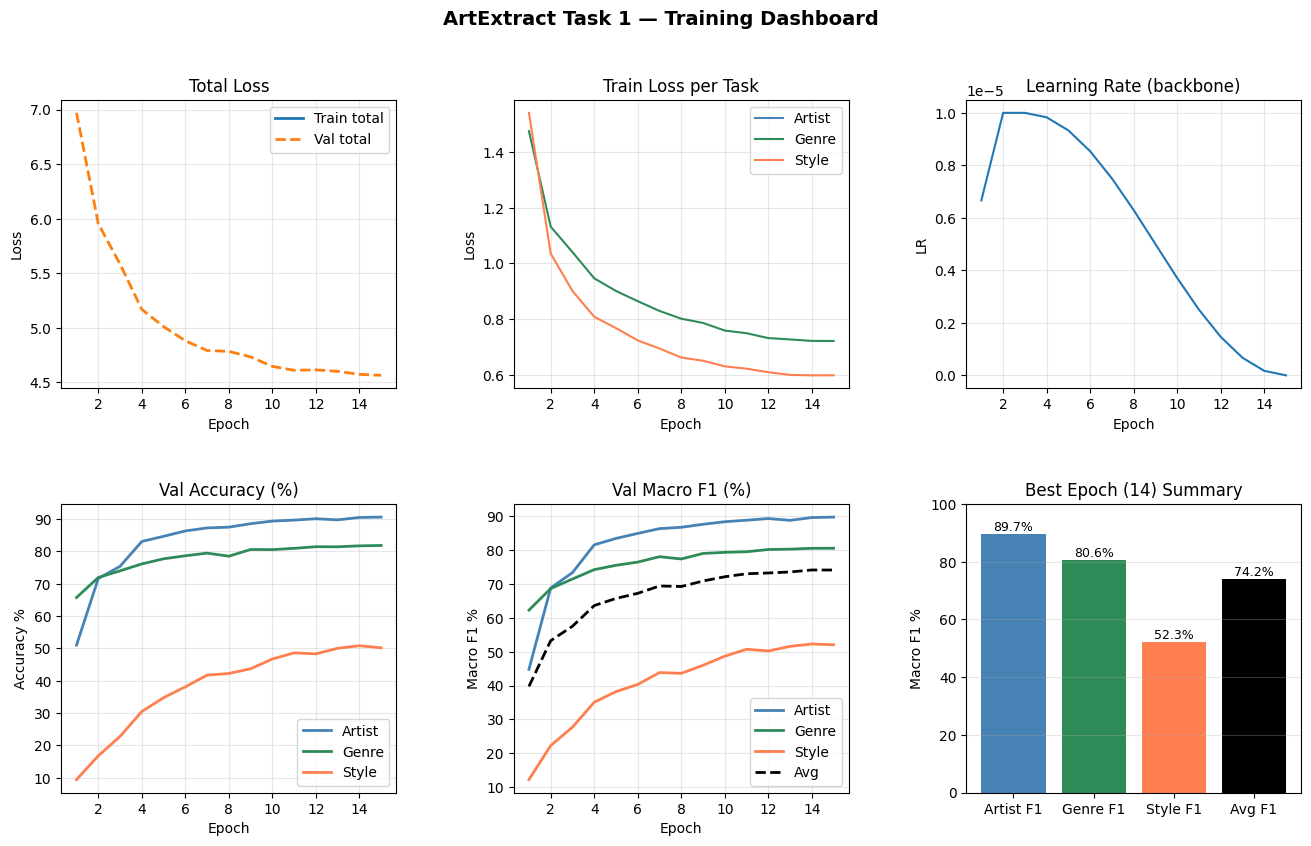

Saved → /kaggle/working/logs/class_distributions.png


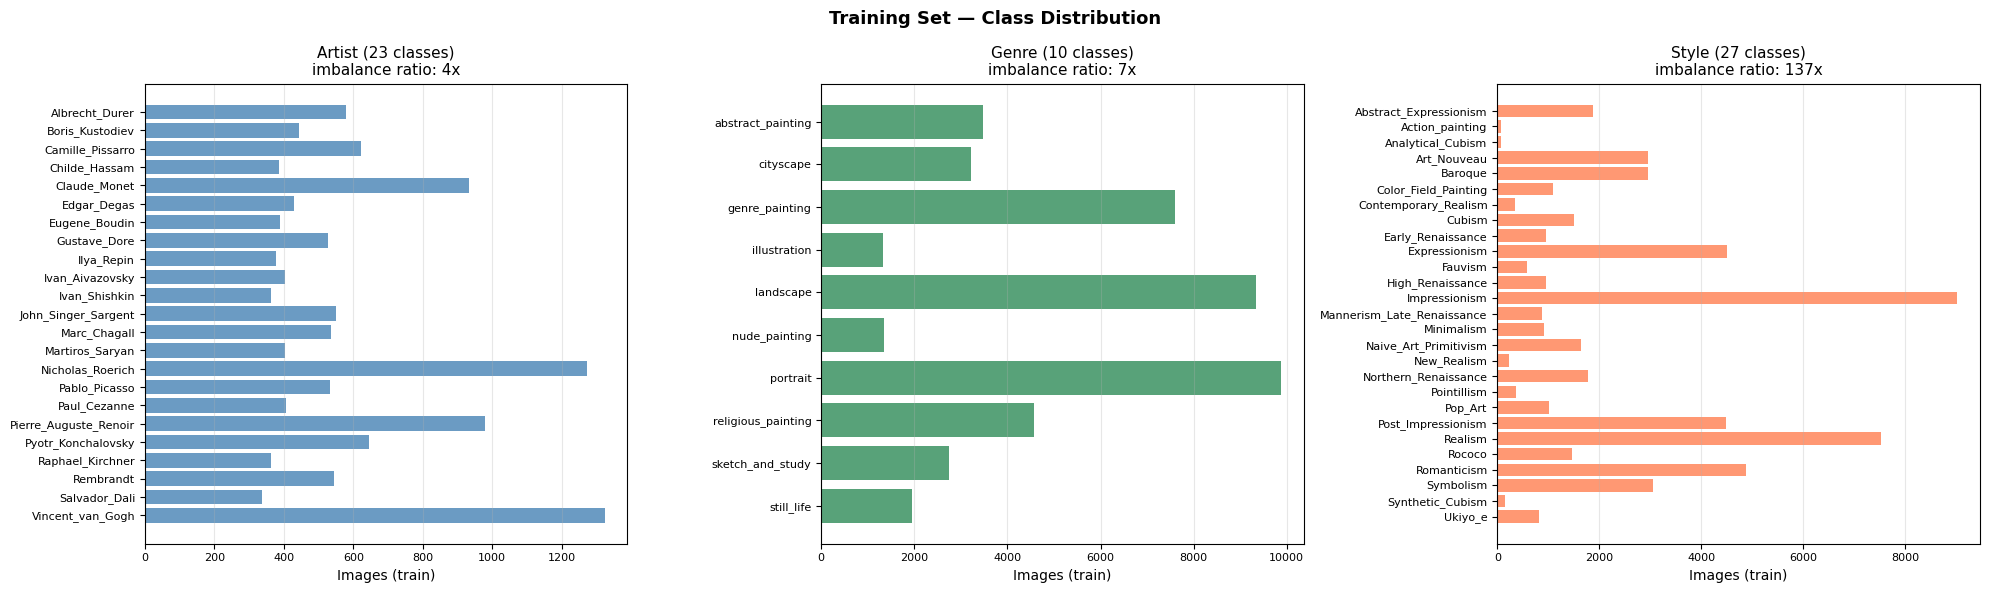

Saved → /kaggle/working/logs/class_weights.png


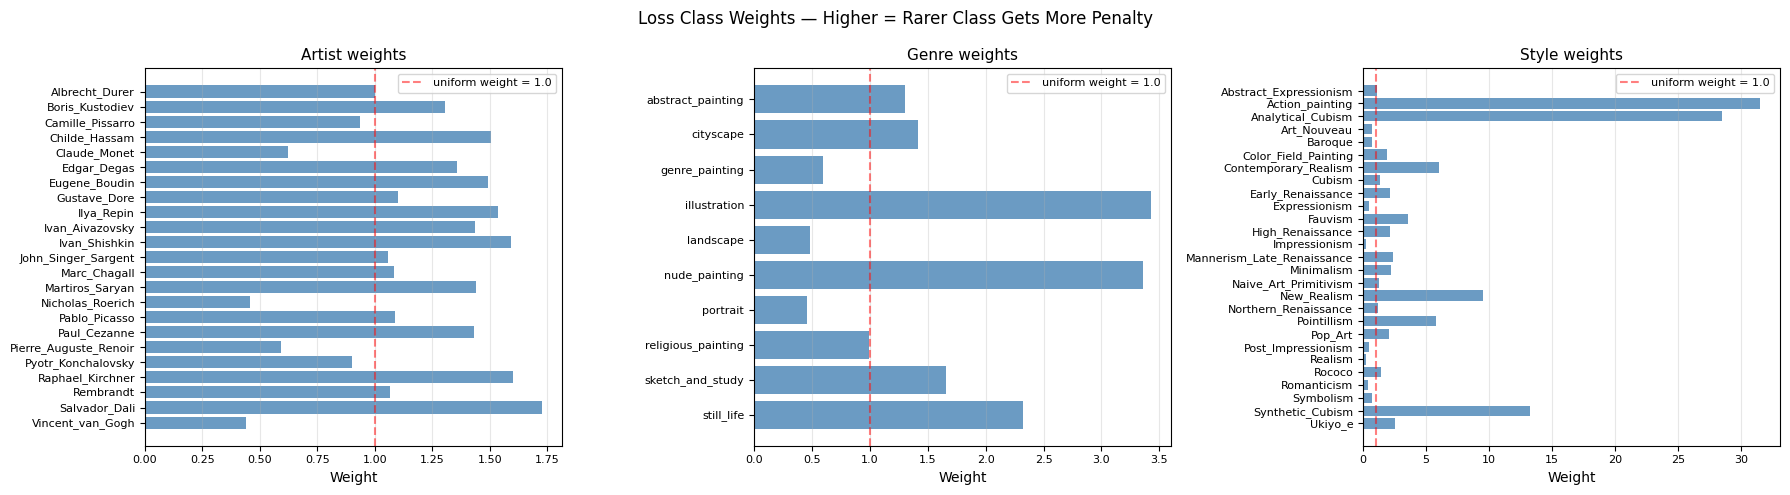

In [ ]:
# Visualisation of Training Curves and Class Distribution


# Load history (if re-running after session) 
# hist = pd.read_csv(os.path.join(LOG_DIR, 'history.csv'))
hist = pd.DataFrame(history)   # use live history during training


# Plot 1: Training curves (2×3 grid)
def plot_training_curves(hist, save_path=None):
    fig = plt.figure(figsize=(16, 9))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    # Row 1: Loss curves 
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(hist.epoch, hist.train_loss, label='Train total', linewidth=2)
    ax.plot(hist.epoch, hist.val_loss,   label='Val total',   linewidth=2, linestyle='--')
    ax.set_title('Total Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[0, 1])
    ax.plot(hist.epoch, hist.train_artist, label='Artist', color='steelblue')
    ax.plot(hist.epoch, hist.train_genre,  label='Genre',  color='seagreen')
    ax.plot(hist.epoch, hist.train_style,  label='Style',  color='coral')
    ax.set_title('Train Loss per Task')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[0, 2])
    ax.plot(hist.epoch, hist.lr)
    ax.set_title('Learning Rate (backbone)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
    ax.grid(alpha=0.3)

    # Row 2: Val Accuracy
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(hist.epoch, hist.artist_acc, label='Artist', color='steelblue', linewidth=2)
    ax.plot(hist.epoch, hist.genre_acc,  label='Genre',  color='seagreen',  linewidth=2)
    ax.plot(hist.epoch, hist.style_acc,  label='Style',  color='coral',     linewidth=2)
    ax.set_title('Val Accuracy (%)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy %')
    ax.legend(); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[1, 1])
    ax.plot(hist.epoch, hist.artist_f1, label='Artist', color='steelblue', linewidth=2)
    ax.plot(hist.epoch, hist.genre_f1,  label='Genre',  color='seagreen',  linewidth=2)
    ax.plot(hist.epoch, hist.style_f1,  label='Style',  color='coral',     linewidth=2)
    ax.plot(hist.epoch, hist.avg_f1,    label='Avg',    color='black',     linewidth=2, linestyle='--')
    ax.set_title('Val Macro F1 (%)')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Macro F1 %')
    ax.legend(); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[1, 2])
    # Show best epoch marker
    best_ep = hist.loc[hist.avg_f1.idxmax()]
    ax.bar(['Artist F1','Genre F1','Style F1','Avg F1'],
           [best_ep.artist_f1, best_ep.genre_f1, best_ep.style_f1, best_ep.avg_f1],
           color=['steelblue','seagreen','coral','black'])
    ax.set_title(f'Best Epoch ({int(best_ep.epoch)}) Summary')
    ax.set_ylabel('Macro F1 %')
    ax.set_ylim(0, 100)
    for i, v in enumerate([best_ep.artist_f1, best_ep.genre_f1, best_ep.style_f1, best_ep.avg_f1]):
        ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)
    ax.grid(alpha=0.3, axis='y')

    fig.suptitle('ArtExtract Task 1 - Training Dashboard', fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()

if history:
    plot_training_curves(hist, save_path=os.path.join(LOG_DIR, 'training_curves.png'))


# Plot 2: Class distribution (before training - run after Snippet 3) 
def plot_class_distributions(train_df, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    for ax, col, class_list, title, color in [
        (axes[0], 'artist_name', ARTIST_CLASSES, 'Artist (23 classes)', 'steelblue'),
        (axes[1], 'genre_name',  GENRE_CLASSES,  'Genre (10 classes)',  'seagreen'),
        (axes[2], 'style_name',  STYLE_CLASSES,  'Style (27 classes)',  'coral'),
    ]:
        sub   = train_df[train_df[col] != 'unknown']
        counts = sub[col].value_counts()
        # Reindex to ensure consistent class order
        counts = counts.reindex([c for c in class_list if c in counts.index], fill_value=0)

        ax.barh(counts.index, counts.values, color=color, alpha=0.8)
        ax.set_title(f'{title}\nimbalance ratio: {counts.max()/max(counts.min(),1):.0f}x', fontsize=11)
        ax.set_xlabel('Images (train)')
        ax.tick_params(labelsize=8)
        ax.invert_yaxis()
        ax.grid(alpha=0.3, axis='x')

    plt.suptitle('Training Set - Class Distribution', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()

plot_class_distributions(train_df, save_path=os.path.join(LOG_DIR, 'class_distributions.png'))


# Plot 3: Class weights heatmap (verify imbalance correction)
def plot_class_weights(w_artist, w_genre, w_style, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, weights, class_list, title in [
        (axes[0], w_artist.cpu().numpy(), ARTIST_CLASSES, 'Artist weights'),
        (axes[1], w_genre.cpu().numpy(),  GENRE_CLASSES,  'Genre weights'),
        (axes[2], w_style.cpu().numpy(),  STYLE_CLASSES,  'Style weights'),
    ]:
        bars = ax.barh(class_list, weights, color='steelblue', alpha=0.8)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Weight')
        ax.tick_params(labelsize=8)
        ax.invert_yaxis()
        ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='uniform weight = 1.0')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3, axis='x')

    plt.suptitle('Loss Class Weights - Higher = Rarer Class Gets More Penalty', fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()

plot_class_weights(w_artist, w_genre, w_style,
                   save_path=os.path.join(LOG_DIR, 'class_weights.png'))

In [22]:
import os
for f in os.listdir('/kaggle/working/checkpoints'):
    size = os.path.getsize(f'/kaggle/working/checkpoints/{f}') / 1e6
    print(f'{f}  —  {size:.1f} MB')

ckpt_ep10.pth  —  854.7 MB
ckpt_ep5.pth  —  854.6 MB
ckpt_best.pth  —  854.7 MB
ckpt_ep15.pth  —  854.7 MB


In [23]:
# Load best model
start_ep, best_metrics, _ = load_checkpoint(model, optimizer, scheduler, 'best')
print(f"Best epoch: {start_ep}")
print(f"Artist F1: {best_metrics['artist_f1']}%")
print(f"Genre  F1: {best_metrics['genre_f1']}%")
print(f"Style  F1: {best_metrics['style_f1']}%")
print(f"Avg    F1: {best_metrics['avg_f1']}%")

  Loaded ← /kaggle/working/checkpoints/ckpt_best.pth  (epoch 14)
Best epoch: 14
Artist F1: 89.65%
Genre  F1: 80.57%
Style  F1: 52.3%
Avg    F1: 74.17%


In [24]:
# Recreate val loader without persistent_workers for evaluation
val_loader_eval = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE * 2,
    shuffle     = False,
    num_workers = 4,
    pin_memory  = True,
    # no persistent_workers — avoids dead worker issue post-training
)

In [ ]:
# Full Evaluation + Confusion Matrices + Outlier Detection


from sklearn.metrics import (
    confusion_matrix, classification_report,
    top_k_accuracy_score, f1_score, accuracy_score
)
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import os

# ── Step 0: Load best checkpoint ─────────────────────────────────────
start_ep, best_metrics, _ = load_checkpoint(model, optimizer, scheduler, 'best')
print(f"Loaded best checkpoint from epoch {start_ep}")
print(f"Saved metrics — Artist F1: {best_metrics.get('artist_f1')}% | "
      f"Genre F1: {best_metrics.get('genre_f1')}% | "
      f"Style F1: {best_metrics.get('style_f1')}% | "
      f"Avg F1: {best_metrics.get('avg_f1')}%")

  Loaded ← /kaggle/working/checkpoints/ckpt_best.pth  (epoch 14)
Loaded best checkpoint from epoch 14
Saved metrics — Artist F1: 89.65% | Genre F1: 80.57% | Style F1: 52.3% | Avg F1: 74.17%


In [ ]:
# Collects preds, labels, probs, embeddings, per-sample loss


model.eval()

# Storage
all_preds      = {t: [] for t in ('artist', 'genre', 'style')}
all_labels     = {t: [] for t in ('artist', 'genre', 'style')}
all_probs      = {t: [] for t in ('artist', 'genre', 'style')}
all_embeddings = []
all_fnames     = []
all_losses     = {t: [] for t in ('artist', 'genre', 'style')}

# Per-sample loss functions (no reduction — one value per image)
ce_artist_sample = nn.CrossEntropyLoss(
    weight=w_artist.cpu(), ignore_index=-1, reduction='none', label_smoothing=0.1
)
ce_genre_sample  = nn.CrossEntropyLoss(
    weight=w_genre.cpu(),  ignore_index=-1, reduction='none', label_smoothing=0.1
)
ce_style_sample  = nn.CrossEntropyLoss(
    weight=w_style.cpu(),  ignore_index=-1, reduction='none', label_smoothing=0.1
)

with torch.no_grad():
    for batch in tqdm(val_loader_eval, desc='Full eval pass'):
        imgs = batch['image'].to(DEVICE, memory_format=torch.channels_last)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            out = model(imgs)

        # Embeddings
        all_embeddings.append(out['embedding'].cpu().numpy())
        all_fnames.extend(batch['fname'])

        for task, id_key, ce_fn in [
            ('artist', 'artist_id', ce_artist_sample),
            ('genre',  'genre_id',  ce_genre_sample),
            ('style',  'style_id',  ce_style_sample),
        ]:
            labels = batch[id_key]
            logits = out[task]
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(dim=1).cpu().numpy()
            labs   = labels.numpy()

            # Per-sample loss (NaN for unlabelled rows)
            losses = ce_fn(logits.cpu().float(), labels).numpy()

            mask = labs >= 0
            all_preds[task].extend(preds[mask])
            all_labels[task].extend(labs[mask])
            all_probs[task].append(probs[mask])
            all_losses[task].extend(losses[mask].tolist())
            # Store -1 for unmasked so fnames align
            # (we'll filter by task when building outlier df)

# Convert to arrays
embeddings = np.concatenate(all_embeddings, axis=0)
for task in ('artist', 'genre', 'style'):
    all_probs[task] = np.concatenate(all_probs[task], axis=0)

Full eval pass: 100%|██████████| 375/375 [07:14<00:00,  1.16s/it]


In [ ]:
# Metrics: Macro F1, Top-1, Top-5

task_classes = {
    'artist': ARTIST_CLASSES,
    'genre':  GENRE_CLASSES,
    'style':  STYLE_CLASSES,
}

print("\n" + "="*65)
print("EVALUATION METRICS")
print("="*65)

metrics_summary = {}
for task, class_list in task_classes.items():
    p   = np.array(all_preds[task])
    t   = np.array(all_labels[task])
    prb = all_probs[task]

    top1 = accuracy_score(t, p) * 100
    macro_f1 = f1_score(t, p, average='macro', zero_division=0) * 100

    # Top-5 (only meaningful if n_classes > 5)
    if len(class_list) > 5:
        top5 = top_k_accuracy_score(t, prb, k=5) * 100
    else:
        top5 = 100.0   # trivially 100 for 10 genre classes with k=5 is still valid

    metrics_summary[task] = {
        'top1': round(top1, 2),
        'top5': round(top5, 2),
        'macro_f1': round(macro_f1, 2),
    }

    print(f"\n{task.upper()} ({len(class_list)} classes)")
    print(f"  Top-1 Accuracy : {top1:.2f}%")
    print(f"  Top-5 Accuracy : {top5:.2f}%")
    print(f"  Macro F1       : {macro_f1:.2f}%")
    print(f"\n  Per-class breakdown:")
    report = classification_report(
        t, p, target_names=class_list, zero_division=0, digits=3
    )
    print(report)

# Save metrics
pd.DataFrame(metrics_summary).to_csv(
    os.path.join(LOG_DIR, 'final_metrics.csv')
)


EVALUATION METRICS

ARTIST (23 classes)
  Top-1 Accuracy : 90.50%
  Top-5 Accuracy : 97.97%
  Macro F1       : 89.65%

  Per-class breakdown:
                       precision    recall  f1-score   support

       Albrecht_Durer      0.976     0.964     0.970       248
      Boris_Kustodiev      0.754     0.841     0.795       189
     Camille_Pissarro      0.918     0.842     0.878       266
        Childe_Hassam      0.948     0.891     0.919       165
         Claude_Monet      0.904     0.897     0.901       400
          Edgar_Degas      0.803     0.913     0.854       183
        Eugene_Boudin      0.903     0.958     0.930       166
         Gustave_Dore      0.982     0.969     0.975       225
           Ilya_Repin      0.836     0.758     0.795       161
      Ivan_Aivazovsky      0.960     0.960     0.960       173
        Ivan_Shishkin      0.891     0.942     0.916       156
  John_Singer_Sargent      0.833     0.826     0.829       235
         Marc_Chagall      0.959     

Saved → /kaggle/working/logs/confusion_artist.png


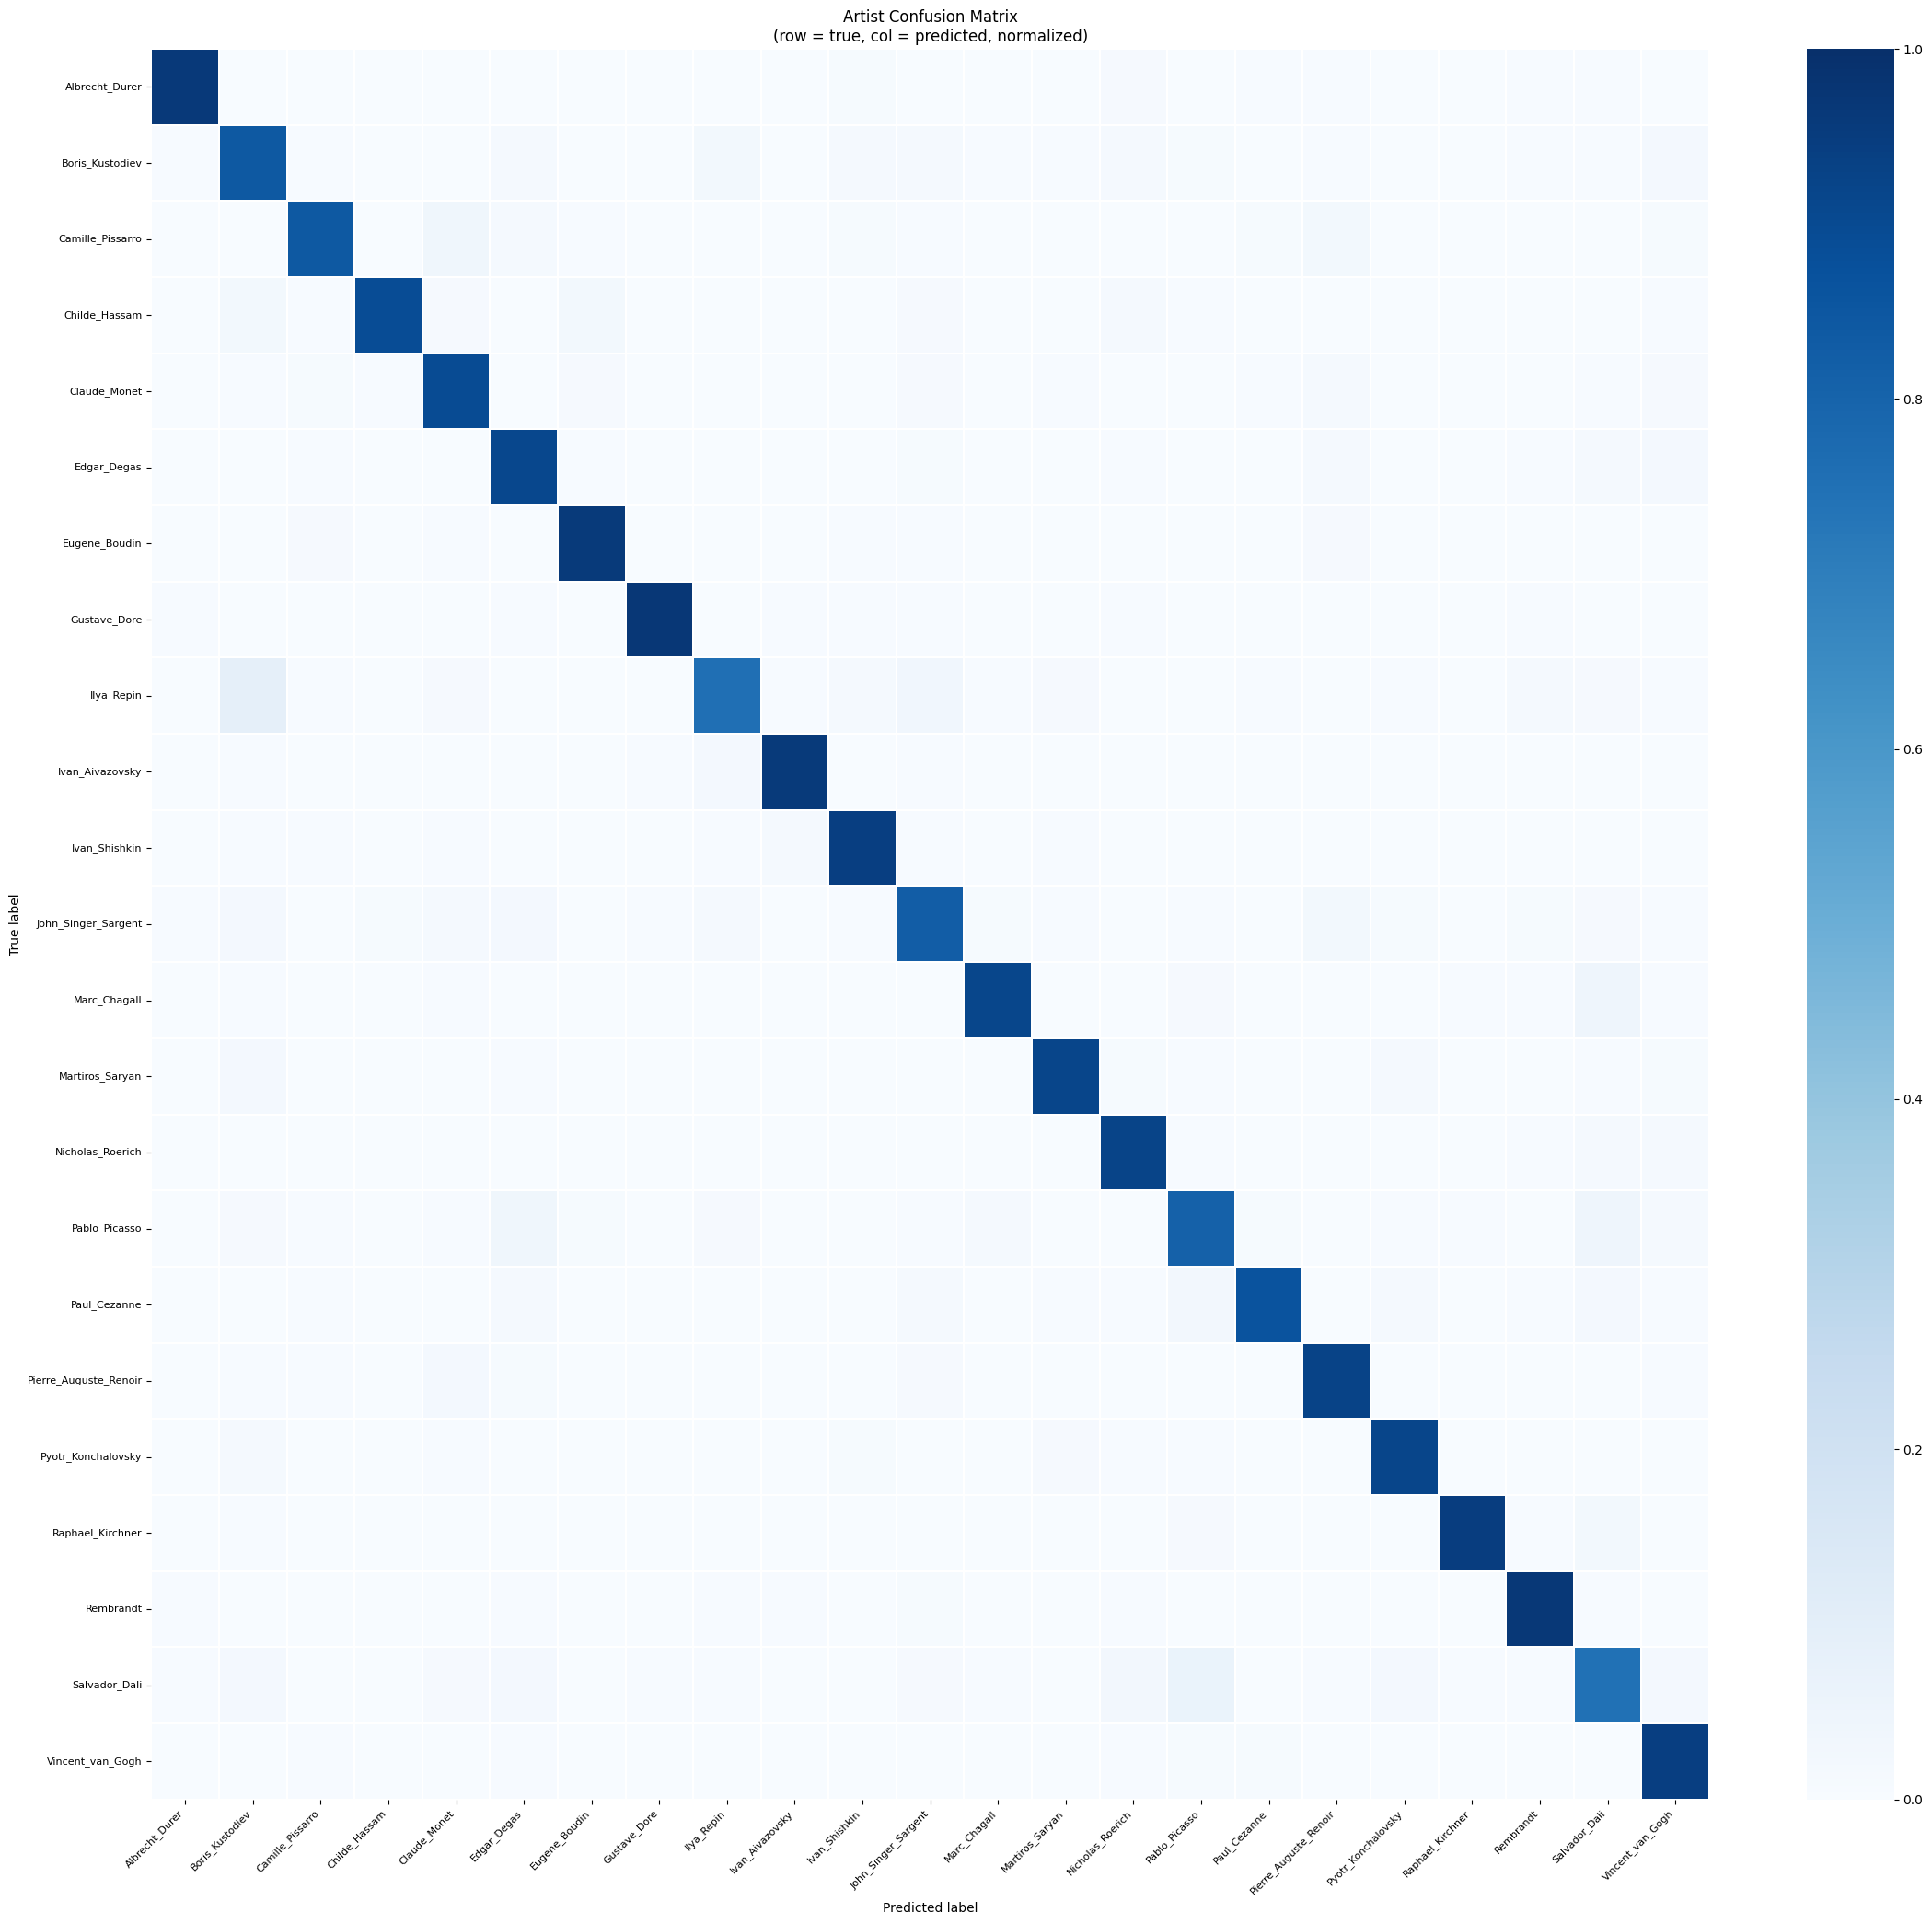

Saved → /kaggle/working/logs/confusion_genre.png


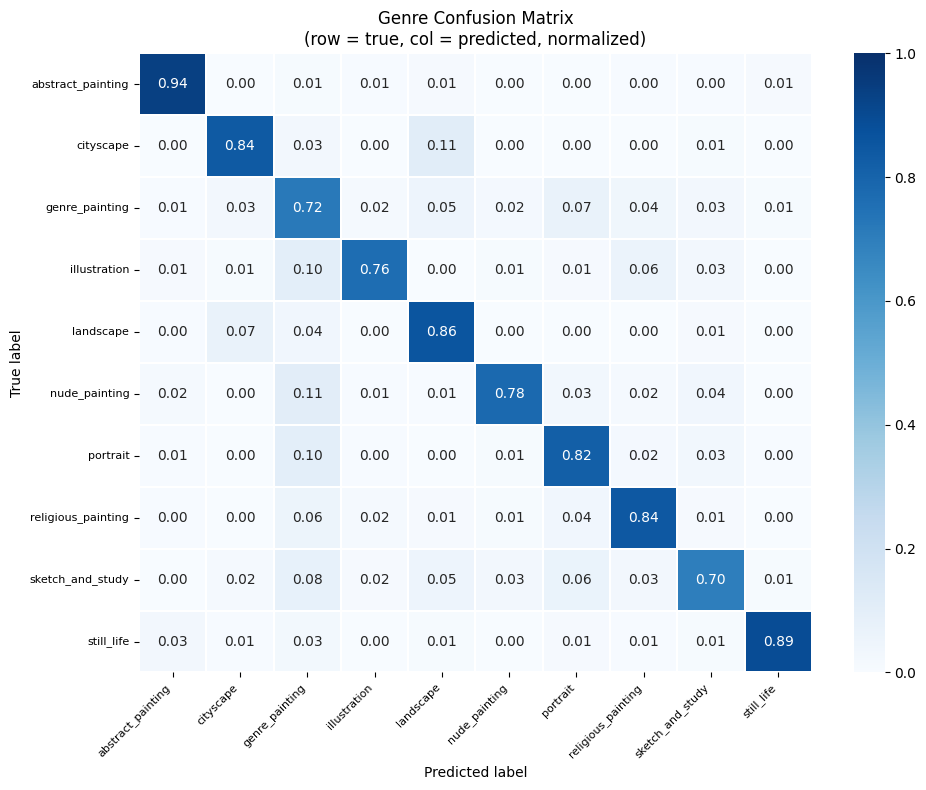

Saved → /kaggle/working/logs/confusion_style.png


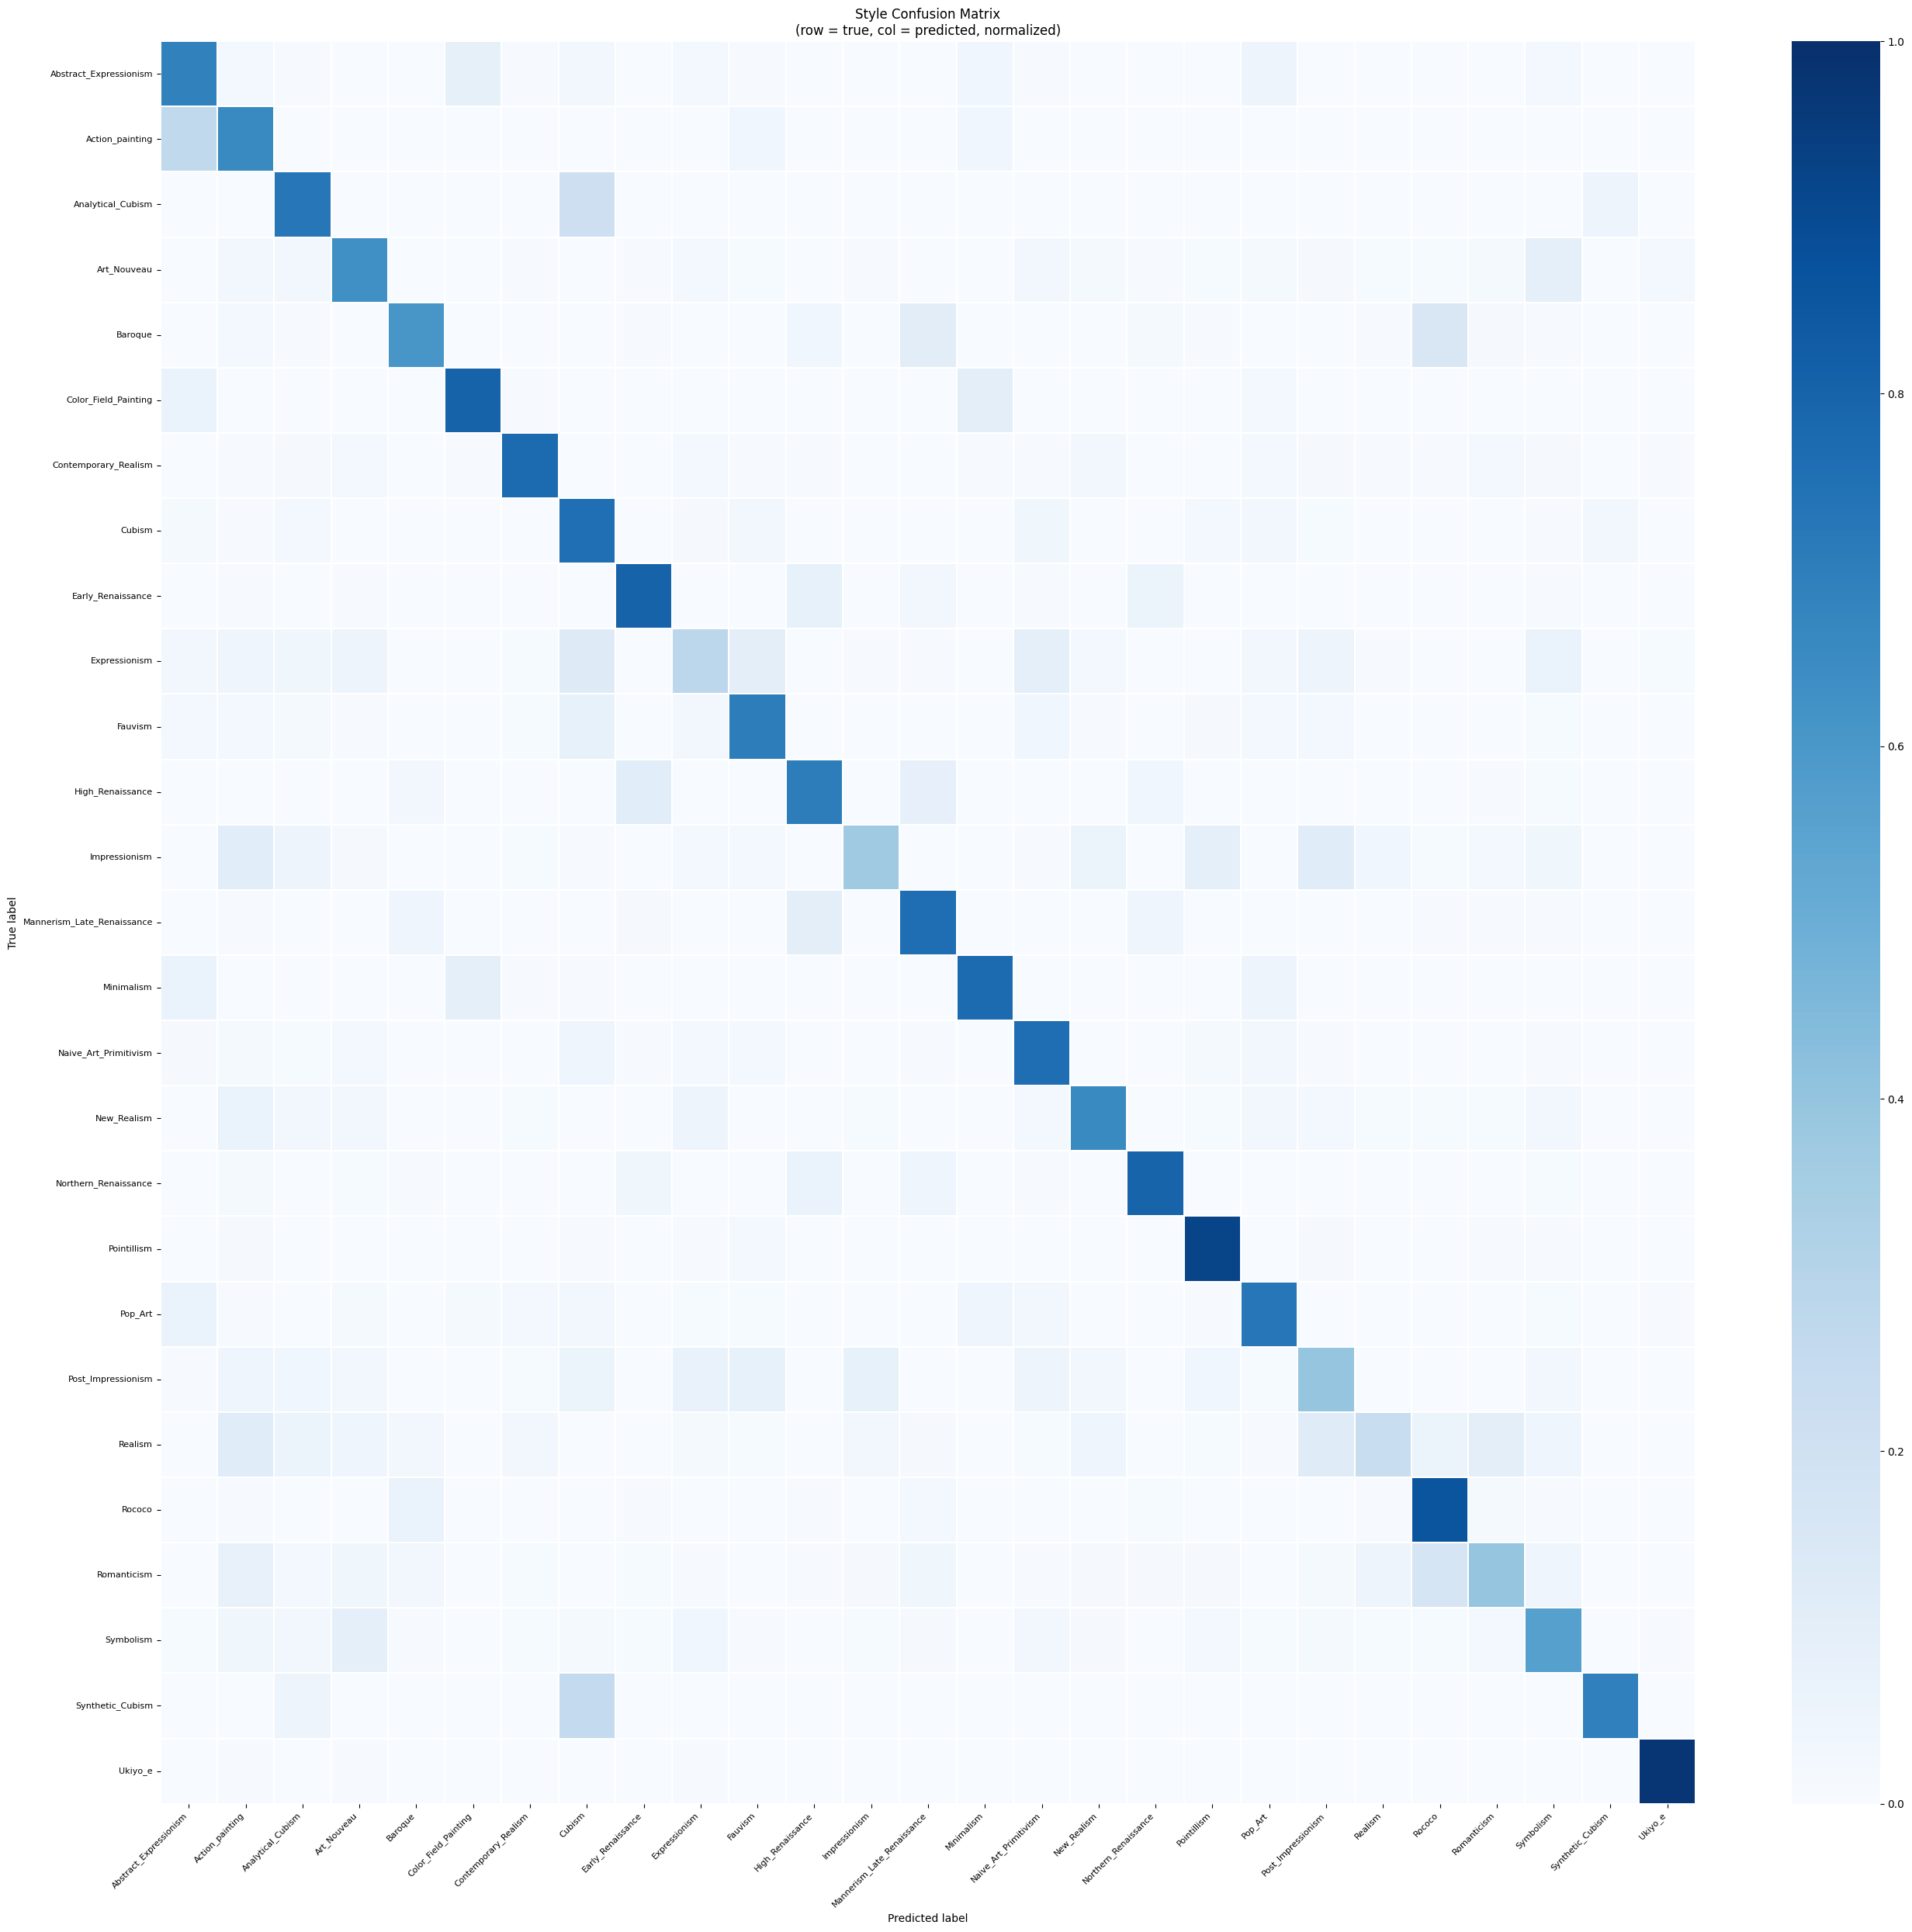

In [ ]:
# Confusion Matrices


def plot_confusion_matrix(p, t, class_names, title, save_path=None):
    cm = confusion_matrix(t, p, normalize='true')
    fig, ax = plt.subplots(figsize=(max(10, len(class_names)), max(8, len(class_names)-2)))
    sns.heatmap(
        cm,
        annot=(len(class_names) <= 15),   # only show numbers if not too many classes
        fmt='.2f',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        linewidths=0.3,
        vmin=0, vmax=1,
    )
    ax.set_title(f'{title}\n(row = true, col = predicted, normalized)', fontsize=12)
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight')
        print(f"Saved → {save_path}")
    plt.show()

for task, class_list in task_classes.items():
    plot_confusion_matrix(
        np.array(all_preds[task]),
        np.array(all_labels[task]),
        class_list,
        title=f'{task.capitalize()} Confusion Matrix',
        save_path=os.path.join(LOG_DIR, f'confusion_{task}.png')
    )

In [ ]:
# Outlier Detection Method 1: Per-Sample Loss Ranking
# Highest loss = model strongly disagrees with the assigned label


print("\n" + "="*65)
print("OUTLIER DETECTION — Method 1: Per-Sample Loss Ranking")
print("="*65)


model.eval()
outlier_records = []

with torch.no_grad():
    for batch in tqdm(val_loader_eval, desc='Outlier loss pass'):
        imgs   = batch['image'].to(DEVICE, memory_format=torch.channels_last)
        fnames = batch['fname']

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            out = model(imgs)

        B = imgs.size(0)
        for i in range(B):
            record = {'fname': fnames[i]}
            for task, id_key, ce_fn, class_list in [
                ('artist', 'artist_id', ce_artist_sample, ARTIST_CLASSES),
                ('genre',  'genre_id',  ce_genre_sample,  GENRE_CLASSES),
                ('style',  'style_id',  ce_style_sample,  STYLE_CLASSES),
            ]:
                label = batch[id_key][i].item()
                if label >= 0:
                    loss_val = ce_fn(
                        out[task][i:i+1].cpu().float(),
                        batch[id_key][i:i+1]
                    ).item()
                    pred_cls  = out[task][i].argmax().item()
                    true_name = class_list[label]
                    pred_name = class_list[pred_cls]
                    record[f'{task}_true']    = true_name
                    record[f'{task}_pred']    = pred_name
                    record[f'{task}_loss']    = round(loss_val, 4)
                    record[f'{task}_correct'] = int(label == pred_cls)
                else:
                    record[f'{task}_true']    = 'unknown'
                    record[f'{task}_pred']    = 'unknown'
                    record[f'{task}_loss']    = np.nan
                    record[f'{task}_correct'] = -1
            outlier_records.append(record)

outlier_df = pd.DataFrame(outlier_records)

# Top outliers per task — wrong predictions with highest loss
print("\nTop 15 ARTIST outliers (highest loss, wrong prediction):")
artist_out = (outlier_df[
    (outlier_df.artist_correct == 0) & (outlier_df.artist_true != 'unknown')
].nlargest(15, 'artist_loss')[['fname','artist_true','artist_pred','artist_loss']])
print(artist_out.to_string(index=False))

print("\nTop 15 GENRE outliers:")
genre_out = (outlier_df[
    (outlier_df.genre_correct == 0) & (outlier_df.genre_true != 'unknown')
].nlargest(15, 'genre_loss')[['fname','genre_true','genre_pred','genre_loss']])
print(genre_out.to_string(index=False))

print("\nTop 15 STYLE outliers:")
style_out = (outlier_df[
    (outlier_df.style_correct == 0) & (outlier_df.style_true != 'unknown')
].nlargest(15, 'style_loss')[['fname','style_true','style_pred','style_loss']])
print(style_out.to_string(index=False))

outlier_df.to_csv(os.path.join(LOG_DIR, 'outliers_by_loss.csv'), index=False)
print(f"\nFull outlier table saved → {LOG_DIR}/outliers_by_loss.csv")


OUTLIER DETECTION — Method 1: Per-Sample Loss Ranking


Outlier loss pass: 100%|██████████| 375/375 [07:17<00:00,  1.17s/it]



Top 15 ARTIST outliers (highest loss, wrong prediction):
                                                                                  fname     artist_true         artist_pred  artist_loss
                                         martiros-saryan_portrait-of-anna-akhmatova.jpg Martiros_Saryan     Boris_Kustodiev       7.5255
                                      boris-kustodiev_english-wonders-buremetr-1926.jpg Boris_Kustodiev       Pablo_Picasso       7.1179
                                                ilya-repin_landscape-with-boat-1875.jpg      Ilya_Repin       Ivan_Shishkin       6.9292
                                            paul-cezanne_luncheon-on-the-grass-1869.jpg    Paul_Cezanne       Salvador_Dali       6.9077
ivan-shishkin_ivan-shishkin-and-a-guinet-in-the-studio-on-the-island-of-valaam-1860.jpg   Ivan_Shishkin     Boris_Kustodiev       6.6286
                                      salvador-dali_don-salvador-and-ana-maria-dali.jpg   Salvador_Dali     Boris_Kustod

In [ ]:
# Outlier Detection Method 2: Embedding Distance
# Cosine distance from class centroid in embedding space
# Paintings far from their class cluster = stylistic outliers


print("\n" + "="*65)
print("OUTLIER DETECTION — Method 2: Embedding Distance from Centroid")
print("="*65)

def embedding_outliers(embeddings, labels, class_names, fnames, top_k=10):
    """
    For each class, compute cosine distance of each member from class centroid.
    Returns dataframe sorted by distance descending.
    """
    records = []
    for cls_idx, cls_name in enumerate(class_names):
        mask     = np.array(labels) == cls_idx
        if mask.sum() < 3:
            continue
        cls_embs = embeddings[mask]
        cls_fnames = [f for f, m in zip(fnames, mask) if m]
        centroid = cls_embs.mean(axis=0, keepdims=True)
        dists    = cdist(cls_embs, centroid, metric='cosine').ravel()
        top_idxs = np.argsort(dists)[-top_k:]
        for idx in top_idxs:
            records.append({
                'fname':        cls_fnames[idx],
                'true_class':   cls_name,
                'cosine_dist':  round(float(dists[idx]), 4),
            })
    return pd.DataFrame(records).sort_values('cosine_dist', ascending=False)

# Style embedding outliers (most interesting — 27 classes)
style_labels_full = []
style_fnames_full = []
style_embs_full   = []

model.eval()
with torch.no_grad():
    for batch in tqdm(val_loader_eval, desc='Embedding pass'):
        imgs = batch['image'].to(DEVICE, memory_format=torch.channels_last)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            out = model(imgs)
        for i, fname in enumerate(batch['fname']):
            label = batch['style_id'][i].item()
            if label >= 0:
                style_labels_full.append(label)
                style_fnames_full.append(fname)
                style_embs_full.append(out['embedding'][i].cpu().numpy())

style_embs_arr = np.stack(style_embs_full)

emb_outliers = embedding_outliers(
    style_embs_arr, style_labels_full, STYLE_CLASSES, style_fnames_full, top_k=5
)
print("\nTop 30 style outliers by embedding distance from class centroid:")
print(emb_outliers.head(30).to_string(index=False))
emb_outliers.to_csv(os.path.join(LOG_DIR, 'outliers_by_embedding.csv'), index=False)


OUTLIER DETECTION — Method 2: Embedding Distance from Centroid


Embedding pass: 100%|██████████| 375/375 [07:11<00:00,  1.15s/it]



Top 30 style outliers by embedding distance from class centroid:
                                                                                                  fname             true_class  cosine_dist
                                                           georgia-o'keeffe_green-yellow-and-orange.jpg Abstract_Expressionism       1.1133
                                           auguste-rodin_monument-to-victor-hugo-first-project-1890.jpg          Impressionism       1.1097
                                                                    auguste-rodin_eternal-idol-1889.jpg          Impressionism       1.0969
                                                                 eliseu-visconti_self-portrait-1902.jpg          Impressionism       1.0897
                                                auguste-rodin_young-girl-with-roses-on-her-hat-1870.jpg          Impressionism       1.0773
                                                               auguste-rodin_the-burghers-of-c


Running t-SNE (this takes 2-3 minutes)...
Saved → /kaggle/working/logs/tsne_style.png


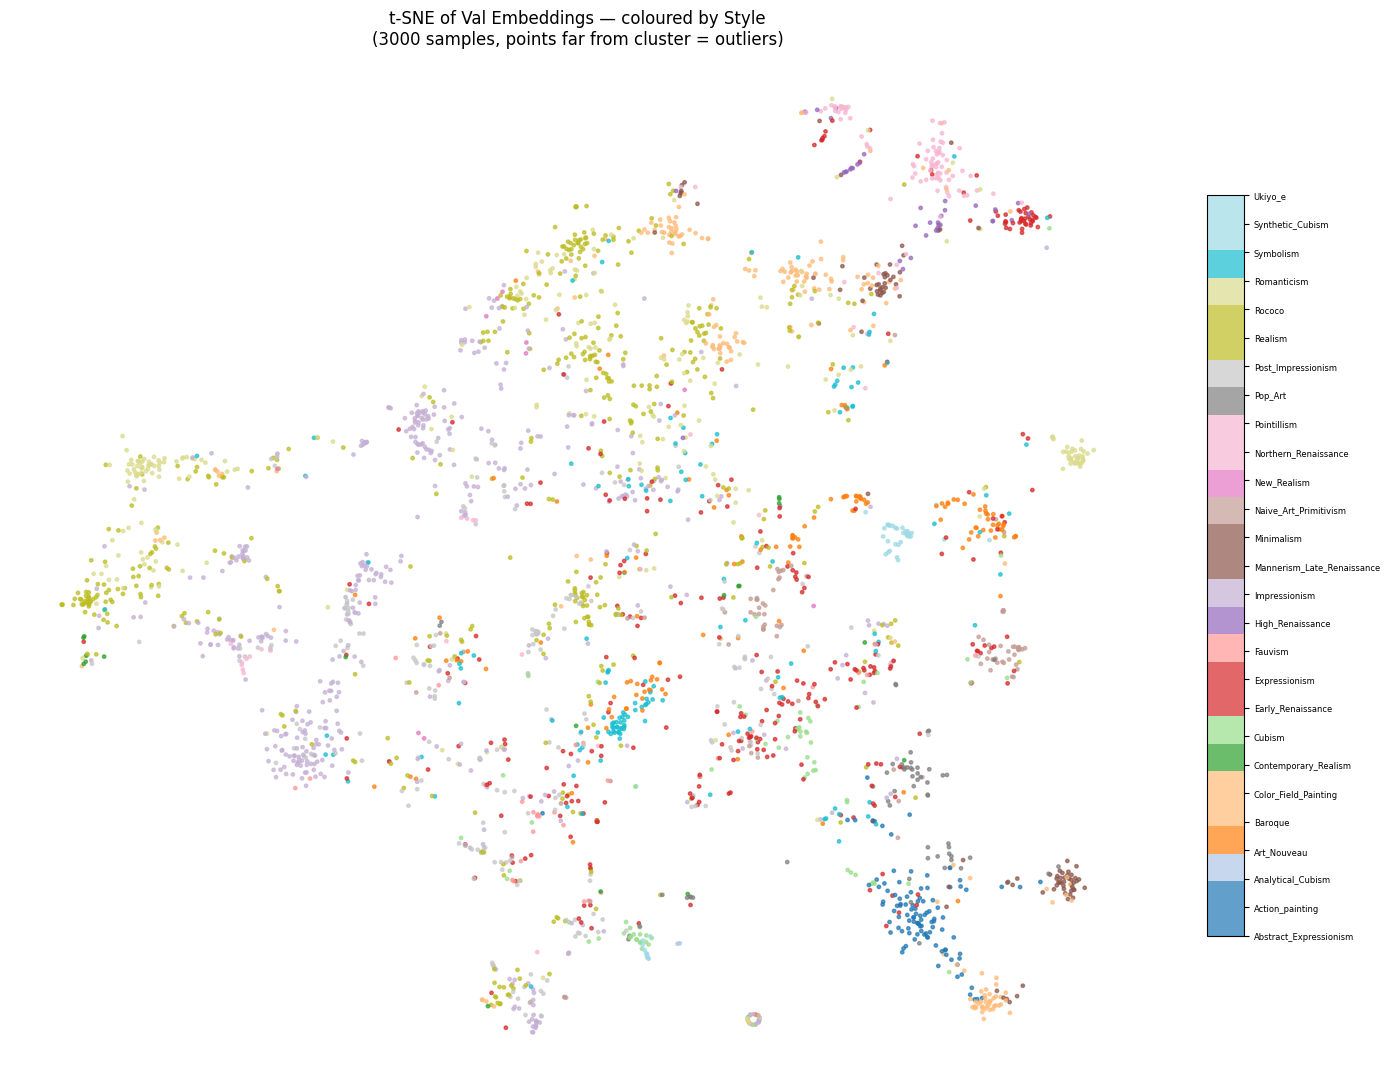

In [ ]:
# t-SNE Visualisation of Embeddings
# Outliers visible as points far from their colour cluster

print("\nRunning t-SNE (this takes 2-3 minutes)...")

# Subsample for speed — t-SNE is O(n²)
N_TSNE   = min(3000, len(style_embs_arr))
idx_sample = np.random.choice(len(style_embs_arr), N_TSNE, replace=False)
emb_sample = style_embs_arr[idx_sample]
lbl_sample = np.array(style_labels_full)[idx_sample]

tsne   = TSNE(n_components=2, perplexity=40, n_iter=1000,
              random_state=SEED, verbose=0)
coords = tsne.fit_transform(emb_sample)

fig, ax = plt.subplots(figsize=(14, 11))
cmap    = plt.cm.get_cmap('tab20', N_STYLE)
scatter = ax.scatter(
    coords[:, 0], coords[:, 1],
    c=lbl_sample, cmap=cmap,
    s=6, alpha=0.7,
)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(N_STYLE), fraction=0.03)
cbar.set_ticklabels(STYLE_CLASSES, fontsize=6)
ax.set_title(
    f't-SNE of Val Embeddings — coloured by Style\n'
    f'({N_TSNE} samples, points far from cluster = outliers)',
    fontsize=12
)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, 'tsne_style.png'), dpi=150, bbox_inches='tight')
print(f"Saved → {LOG_DIR}/tsne_style.png")
plt.show()

In [ ]:
# Summary Table 
print("\n" + "="*65)
print("FINAL SUMMARY")
print("="*65)
print(f"\nModel: ConvNeXt-Small + HRNet-W18 + BiLSTM (1 layer, hidden=256)")
print(f"Image size: {IMG_SIZE}×{IMG_SIZE} | Epochs: {NUM_EPOCHS} | Batch: {BATCH_SIZE}")
print(f"\n{'Task':<10} {'Top-1':>8} {'Top-5':>8} {'Macro F1':>10}")
print("-"*40)
for task in ('artist', 'genre', 'style'):
    m = metrics_summary[task]
    print(f"{task:<10} {m['top1']:>7}%  {m['top5']:>7}%  {m['macro_f1']:>9}%")
avg_f1 = np.mean([metrics_summary[t]['macro_f1'] for t in ('artist','genre','style')])
print(f"\n{'Average':>10}                    {avg_f1:>9.2f}%")

print(f"\nOutlier files saved:")
print(f"  outliers_by_loss.csv      — per-sample CE loss ranking")
print(f"  outliers_by_embedding.csv — cosine distance from centroid")
print(f"  tsne_style.png            — t-SNE embedding visualisation")
print(f"  confusion_artist.png")
print(f"  confusion_genre.png")
print(f"  confusion_style.png")


FINAL SUMMARY

Model: ConvNeXt-Small + HRNet-W18 + BiLSTM (1 layer, hidden=256)
Image size: 256×256 | Epochs: 15 | Batch: 32

Task          Top-1    Top-5   Macro F1
----------------------------------------
artist        90.5%    97.97%      89.65%
genre        81.72%    96.33%      80.57%
style        50.84%    77.99%       52.3%

   Average                        74.17%

Outlier files saved:
  outliers_by_loss.csv      — per-sample CE loss ranking
  outliers_by_embedding.csv — cosine distance from centroid
  tsne_style.png            — t-SNE embedding visualisation
  confusion_artist.png
  confusion_genre.png
  confusion_style.png
